In [3]:
#!pip install ultralytics roboflow

In [8]:
from ultralytics import YOLO
import os, shutil
from roboflow import Roboflow
from PIL import Image
import glob
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import time

In [9]:
import torch
import gc
# clear GPU memory
torch.cuda.empty_cache()
gc.collect()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1024**2:.0f} MB")

GPU memory free: 10937 MB


## Load & Quick test

In [7]:
model = YOLO("yolov8n.pt")

In [9]:
# results = model('https://ultralytics.com/images/bus.jpg')
# results[0].show()

## Download dataset from Roboflow

In [10]:
rf = Roboflow(api_key="NlpA0V39UOOhzCBea0xw")
project = rf.workspace("multiagentproject").project("indoor_detection-mdccv")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## Check dataset structure

In [11]:
dataset_path = dataset.location  # where roboflow saved it

# peek at the yaml
with open(os.path.join(dataset_path, 'data.yaml'), 'r') as f:
    print(f.read())

names:
- Chair
- Sofa
- Table
- bath unit
- bed
- book
- bottle
- cabinet
- chair
- couch
- cup
- cupboard
- curtains
- dining table
- door
- i
- keyboard
- laptop
- mouse
- shower cabinet
- sideboard
- sofa
- trashbin
- tv unit
- wardrobe
- window
nc: 26
roboflow:
  license: Public Domain
  project: indoor_detection-mdccv
  url: https://universe.roboflow.com/multiagentproject/indoor_detection-mdccv/dataset/1
  version: 1
  workspace: multiagentproject
test: ../test/images
train: ../train/images
val: ../valid/images



## Fine-tune

In [ ]:
model.train(
    data=r'C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\indoor_detection-mdccv-1\data.yaml',
    epochs=40,       # reduced, we saw mAP was good at 40 anyway
    imgsz=640,
    batch=16,        # safe batch size
    name='humanoid_final',
    device=0,
    workers=4,       # lowered to reduce RAM pressure
    amp=True,        # NO cache=True
    save=True,       # explicitly force saving
    save_period=10   # saves every 10 epochs as backup
)

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4080 Laptop GPU, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\indoor_detection-1\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=humanoid_yolo

In [12]:
import os

# check both runs
for run in ['humanoid_yolo', 'humanoid_yolo-2']:
    path = rf'C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\runs\detect\{run}\weights'
    if os.path.exists(path):
        print(f"{run}: {os.listdir(path)}")
    else:
        print(f"{run}: folder not found")

humanoid_yolo: []
humanoid_yolo-2: ['best.pt', 'last.pt']


## Validate

In [15]:
# load from yolo2 weights
model = YOLO(r"C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\runs\detect\humanoid_yolo-2\weights\best.pt")

metrics = model.val(
    data=r"C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\indoor_detection-1\data.yaml"
)

print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4080 Laptop GPU, 12282MiB)
Model summary (fused): 73 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 40.817.4 MB/s, size: 31.2 KB)
val: Scanning C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\indoor_detection-1\valid\labels.cache... 826 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 826/826  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 260, len(boxes) = 826. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 9.0it/s 5.8s0.1ss
                   all        826        826      0.695      0.649      0.717       0.71
                 Chair         53         53      

## Test on a real image

In [17]:
trained_model = YOLO(r"C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\runs\detect\humanoid_yolo-2\weights\best.pt")

In [18]:
results = trained_model(r"C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\Door_test.jpeg")

results[0].show()


image 1/1 C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\Door_test.jpeg: 480x640 1 Table, 1 tv unit, 42.3ms
Speed: 3.3ms preprocess, 42.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


In [22]:
# point to any image on your PC
results = trained_model(r"C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\Door_test.jpeg")


image 1/1 C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\Door_test.jpeg: 480x640 1 Table, 1 tv unit, 11.9ms
Speed: 3.4ms preprocess, 11.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


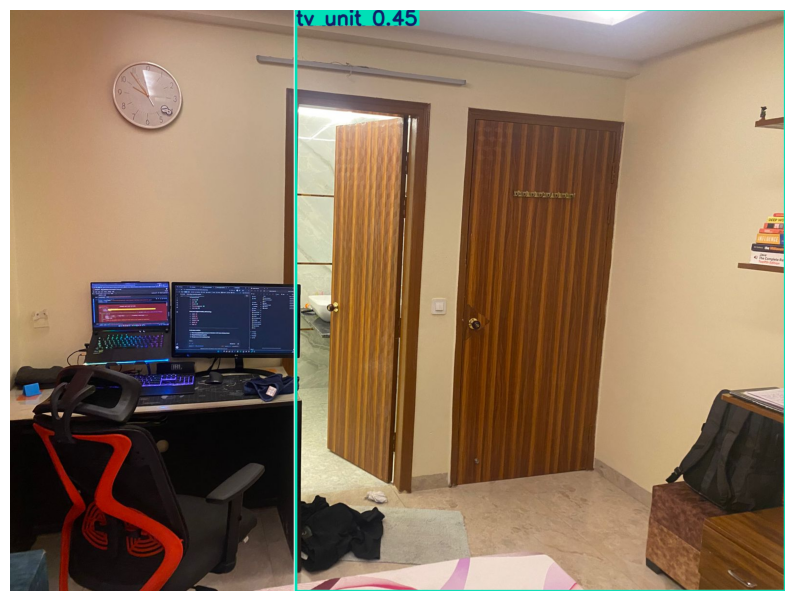

In [23]:
annotated = results[0].plot()
annotated_rgb = annotated[:, :, ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.show()

## Save weights

In [24]:
src = r'C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\runs\detect\humanoid_yolo-2\weights\best.pt'
dst = r'C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\humanoid_best.pt'

shutil.copy(src, dst)

print(f"Saved! ✅")
print(f"Your model is ready at: {dst}")

Saved! ✅
Your model is ready at: C:\Users\Archit\Documents\ML Projects\Humanoid Robot\Object_Detection\humanoid_best.pt


# Testnig the Cam

In [11]:
model = YOLO('yolov8n.pt')

cap = cv2.VideoCapture(1)
prev_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, conf=0.4, verbose=False)
    annotated = results[0].plot()

    # FPS
    curr_time = time.time()
    fps = 1 / (curr_time - prev_time)
    prev_time = curr_time

    cv2.putText(
        annotated, f"FPS: {fps:.2f}", (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2
    )

    cv2.imshow('YOLO Base Test', annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()